# **Step 0: Setup & imports**


In [ ]:
 # data processing
import pandas as pd
# data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
# ignoring the warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from google.colab import files

# **Step 1: Upload files**

In [ ]:
sp500_comp = pd.read_csv('/content/sp500_companies.csv')
sp500_ind = pd.read_csv('/content/sp500_index.csv')
sp500_stock = pd.read_csv('/content/sp500_stocks.csv')

In [ ]:
sp500_stock = pd.read_csv('/content/sp500_stocks.csv')
print(sp500_stock.shape)
print(sp500_stock['Symbol'].nunique())

(1891536, 8)
502


# **Step 2:Data understanding**

In [ ]:
print(sp500_comp.shape, sp500_ind.shape, sp500_stock.shape)

(502, 16) (2517, 2) (1891536, 8)


In [ ]:
sp500_stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891536 entries, 0 to 1891535
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date       object 
 1   Symbol     object 
 2   Adj Close  float64
 3   Close      float64
 4   High       float64
 5   Low        float64
 6   Open       float64
 7   Volume     float64
dtypes: float64(6), object(2)
memory usage: 115.5+ MB


In [ ]:
sp500_stock.sample(10)

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
1554831,2019-08-08,NOW,NaN,NaN,NaN,NaN,NaN,NaN
143099,2024-08-22,AON,NaN,NaN,NaN,NaN,NaN,NaN
1157647,2013-06-20,MCD,71.378769,96.790001,98.680000,96.620003,98.370003,5550100.0
888196,2020-10-16,HRL,44.545944,49.540001,50.619999,49.500000,50.299999,5536400.0
887418,2017-09-14,HRL,26.023056,30.910000,31.340000,30.790001,31.250000,3507500.0
1032168,2023-12-05,KEYS,NaN,NaN,NaN,NaN,NaN,NaN
806107,2024-01-03,GD,NaN,NaN,NaN,NaN,NaN,NaN
739329,2013-03-12,FE,NaN,NaN,NaN,NaN,NaN,NaN
792380,2014-05-19,GEV,NaN,NaN,NaN,NaN,NaN,NaN
1660649,2020-11-04,TFX,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
sp500_stock.describe()#EDA

,Adj Close,Close,High,Low,Open,Volume
count,617831.000000,617831.000000,617831.000000,617831.000000,617831.000000,6.178310e+05
mean,79.672357,87.471540,88.417844,86.480997,87.460302,9.347125e+06
std,102.742931,104.521901,105.684113,103.300770,104.519845,4.771669e+07
min,0.203593,0.222000,0.226250,0.216250,0.218000,0.000000e+00
25%,26.572459,32.700001,33.060001,32.299999,32.689999,1.144000e+06
50%,49.821613,59.139999,59.720001,58.500000,59.119999,2.453400e+06
75%,94.831036,105.019997,106.129997,103.889999,105.000000,5.657850e+06
max,1702.530029,1702.530029,1714.750000,1696.900024,1706.400024,3.692928e+09


In [ ]:
sp500_stock.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,MMM,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,MMM,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
sp500_stock.tail()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
1891531,2024-12-16,ZTS,NaN,NaN,NaN,NaN,NaN,NaN
1891532,2024-12-17,ZTS,NaN,NaN,NaN,NaN,NaN,NaN
1891533,2024-12-18,ZTS,NaN,NaN,NaN,NaN,NaN,NaN
1891534,2024-12-19,ZTS,NaN,NaN,NaN,NaN,NaN,NaN
1891535,2024-12-20,ZTS,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
sp500_stock.nunique()

,0
Date,3768
Symbol,502
Adj Close,525360
Close,123637
High,123036
Low,122480
Open,121187
Volume,208513


# **Step 3: Inspect nulls in the stock prices table**

In [ ]:
print(sp500_stock.isnull().sum())#EDA
print("Total unique symbols:", sp500_stock['Symbol'].nunique())

Date               0
Symbol             0
Adj Close    1273705
Close        1273705
High         1273705
Low          1273705
Open         1273705
Volume       1273705
dtype: int64
Total unique symbols: 502


# **clean**

# **Step 4: Drop symbols with fully-null price data**

In [ ]:
# Flag symbols where every Close value is null #EDA
fully_null = sp500_stock.groupby('Symbol')['Close'].apply(lambda s: s.isnull().all())
symbols_with_data = fully_null[~fully_null].index.tolist()
print("Symbols with actual data:", len(symbols_with_data))

sp500_stock_clean = sp500_stock[sp500_stock['Symbol'].isin(symbols_with_data)].copy()#clean
print(sp500_stock_clean.shape)

Symbols with actual data: 172
(648096, 8)


# **Step 5: Remove remaining nulls and duplicates**

In [ ]:
print(sp500_stock_clean.isnull().sum())

# Drop rows still missing Close or Volume
sp500_stock_clean = sp500_stock_clean.dropna(subset=['Close', 'Volume'])

# Check and remove duplicate (Date, Symbol) rows
print("Duplicate rows:", sp500_stock_clean.duplicated(subset=['Date','Symbol']).sum())
sp500_stock_clean = sp500_stock_clean.drop_duplicates(subset=['Date','Symbol'])

print(sp500_stock_clean.shape)

Date             0
Symbol           0
Adj Close    30265
Close        30265
High         30265
Low          30265
Open         30265
Volume       30265
dtype: int64
Duplicate rows: 0
(617831, 8)


# **Step 6: Merge with company info (Sector/Industry)**

In [ ]:
sp500_stock_clean = sp500_stock_clean.merge(
    sp500_comp[['Symbol', 'Sector', 'Industry', 'Shortname']],
    on='Symbol',
    how='left'
)
print(sp500_stock_clean.shape)
print(sp500_stock_clean['Sector'].isnull().sum())

(617831, 11)
0


# **Step 7: Add derived columns (Year, Month, Daily Return) Feature Engineering**

In [ ]:
sp500_stock_clean['Date'] = pd.to_datetime(sp500_stock_clean['Date'])
sp500_stock_clean['Year'] = sp500_stock_clean['Date'].dt.year
sp500_stock_clean['Month'] = sp500_stock_clean['Date'].dt.month

# Daily return per symbol (% change in Close)
sp500_stock_clean = sp500_stock_clean.sort_values(['Symbol', 'Date'])
sp500_stock_clean['Daily Return'] = sp500_stock_clean.groupby('Symbol')['Close'].pct_change()
sp500_stock_clean['Daily Return'].describe()
sp500_stock_clean['Daily Return'].isnull().sum()
sp500_stock_clean.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume,Year,Month,Daily Return
11304,2010-01-04,ABBV,NaN,NaN,NaN,NaN,NaN,NaN,2010,1,NaN
11305,2010-01-05,ABBV,NaN,NaN,NaN,NaN,NaN,NaN,2010,1,NaN
11306,2010-01-06,ABBV,NaN,NaN,NaN,NaN,NaN,NaN,2010,1,NaN
11307,2010-01-07,ABBV,NaN,NaN,NaN,NaN,NaN,NaN,2010,1,NaN
11308,2010-01-08,ABBV,NaN,NaN,NaN,NaN,NaN,NaN,2010,1,NaN


# **Step 8: Check the Volume = 0 rows we spotted earlier**

In [ ]:
zero_vol = sp500_stock_clean[sp500_stock_clean['Volume'] == 0]
print("Zero-volume rows:", len(zero_vol))
zero_vol['Symbol'].value_counts().head(10)

Zero-volume rows: 7


,count
Symbol,
PFG,2
BKR,1
DXCM,1
GDDY,1
VRTX,1
WTW,1


# **Step 9: Final check & export cleaned data**

In [ ]:
# Quick final sanity check before exporting
print(sp500_stock_clean.shape)
print(sp500_stock_clean.isnull().sum())
print("Symbols:", sp500_stock_clean['Symbol'].nunique())
print(sp500_stock_clean['Sector'].unique())

(617831, 14)
Date              0
Symbol            0
Adj Close         0
Close             0
High              0
Low               0
Open              0
Volume            0
Sector            0
Industry          0
Shortname         0
Year              0
Month             0
Daily Return    172
dtype: int64
Symbols: 172
['Healthcare' 'Consumer Defensive' 'Utilities' 'Financial Services'
 'Basic Materials' 'Industrials' 'Consumer Cyclical' 'Technology' 'Energy'
 'Communication Services' 'Real Estate']


In [ ]:
# Export to CSV
sp500_stock_clean.to_csv('sp500_stock_final.csv', index=False)

from google.colab import files
files.download('sp500_stock_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = sp500_stock_clean.copy()
print(df)

             Date Symbol   Adj Close       Close        High         Low  \
7536   2013-01-02   ABBV   21.629181   35.119999   35.400002   34.099998   
7537   2013-01-03   ABBV   21.450581   34.830002   35.000000   34.160000   
7538   2013-01-04   ABBV   21.179594   34.389999   34.889999   34.250000   
7539   2013-01-07   ABBV   21.222700   34.459999   35.450001   34.150002   
7540   2013-01-08   ABBV   20.760809   33.709999   34.639999   33.360001   
...           ...    ...         ...         ...         ...         ...   
617826 2024-12-16    XYL  120.779999  120.779999  122.570000  120.000000   
617827 2024-12-17    XYL  120.769997  120.769997  121.760002  119.730003   
617828 2024-12-18    XYL  116.919998  116.919998  121.559998  116.879997   
617829 2024-12-19    XYL  116.430000  116.430000  118.919998  116.129997   
617830 2024-12-20    XYL  117.139999  117.139999  118.120003  115.900002   

              Open      Volume       Sector                        Industry  \
7536    

# **EDA (Data Exploration)**

# **EDA — Distribution of Daily Returns**

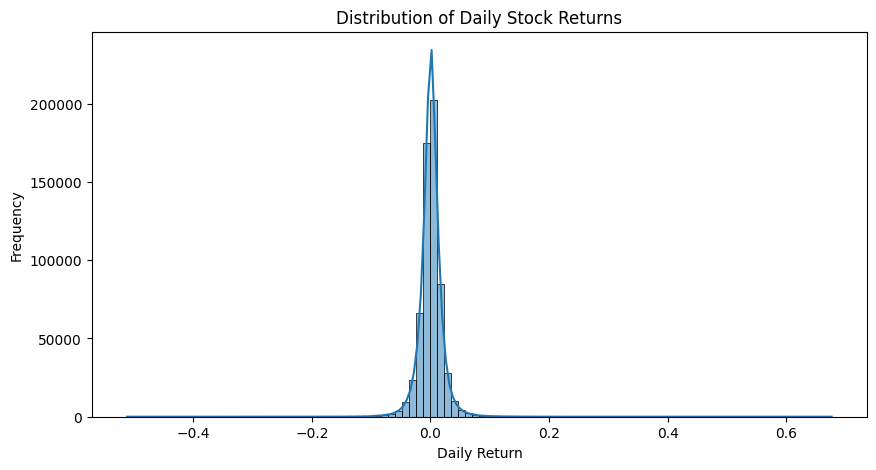

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['Daily Return'].dropna(),
    bins=100,
    kde=True
)

plt.title('Distribution of Daily Stock Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.show()

In [ ]:
df['Daily Return'].describe()#summary

,Daily Return
count,617659.000000
mean,0.000652
std,0.020048
min,-0.511559
25%,-0.008210
50%,0.000714
75%,0.009585
max,0.676812


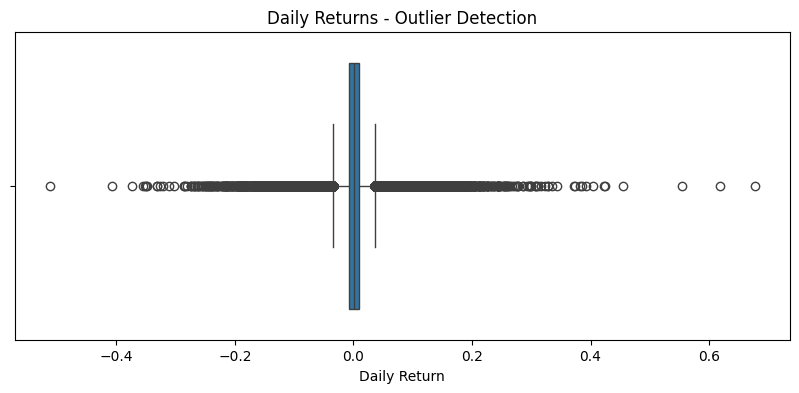

In [ ]:
plt.figure(figsize=(10, 4))#Boxplot outlier

sns.boxplot(
    x=df['Daily Return'].dropna()
)

plt.title('Daily Returns - Outlier Detection')
plt.xlabel('Daily Return')

plt.show()

# **EDA — Sector Distribution**

In [ ]:
sector_counts = (
    df.groupby('Sector')['Symbol']
      .nunique()
      .sort_values(ascending=False)
)

sector_counts

,Symbol
Sector,
Industrials,27
Financial Services,25
Technology,23
Healthcare,21
Consumer Cyclical,18
Real Estate,13
Communication Services,12
Consumer Defensive,12
Utilities,9


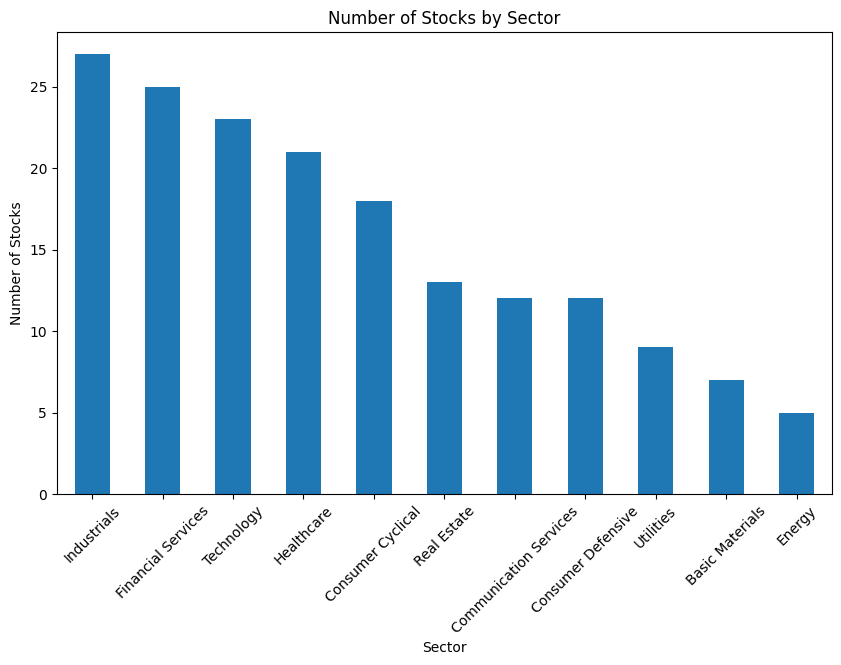

In [ ]:
plt.figure(figsize=(10, 6))

sector_counts.plot(kind='bar')

plt.title('Number of Stocks by Sector')
plt.xlabel('Sector')
plt.ylabel('Number of Stocks')

plt.xticks(rotation=45)
plt.show()

# **EDA — Average Return by Sector**

In [ ]:
sector_return = (
    df.groupby('Sector')['Daily Return']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

sector_return

,Daily Return
Sector,
Technology,0.090593
Consumer Cyclical,0.080005
Industrials,0.074457
Communication Services,0.068837
Healthcare,0.067522
Financial Services,0.061780
Basic Materials,0.051505
Energy,0.050712
Real Estate,0.046309


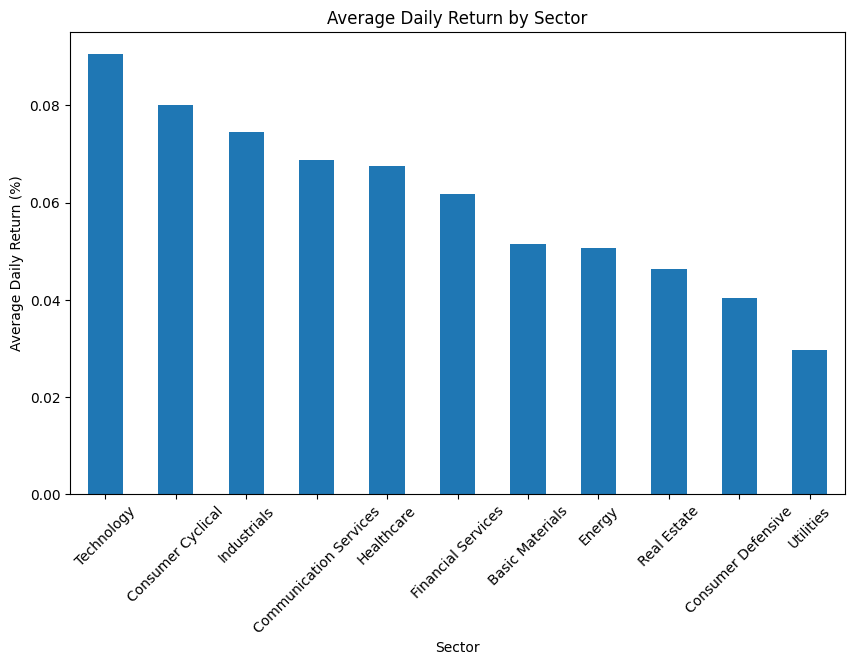

In [ ]:
plt.figure(figsize=(10, 6))

sector_return.plot(kind='bar')

plt.title('Average Daily Return by Sector')
plt.xlabel('Sector')
plt.ylabel('Average Daily Return (%)')

plt.xticks(rotation=45)
plt.show()

# **EDA — Stock Volatility**

In [ ]:
stock_volatility = (
    df.groupby('Symbol')['Daily Return']
      .std()
      .mul(100)
      .sort_values(ascending=False)
)

stock_volatility.head(10)

,Daily Return
Symbol,
ENPH,5.057332
TSLA,3.613228
BLDR,3.487913
UBER,3.381359
FSLR,3.368184
NFLX,3.150711
FCX,3.118366
AXON,3.095082
UAL,3.035935


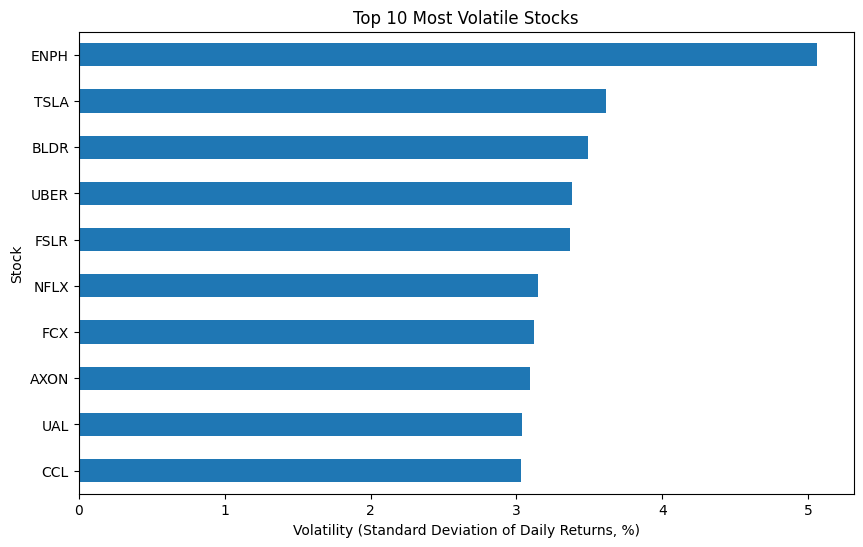

In [ ]:
plt.figure(figsize=(10, 6))

stock_volatility.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Most Volatile Stocks')
plt.xlabel('Volatility (Standard Deviation of Daily Returns, %)')
plt.ylabel('Stock')

plt.show()

# **EDA — Trading Volume**

In [ ]:
avg_volume = (
    df.groupby('Symbol')['Volume']
      .mean()
      .sort_values(ascending=False)
)

avg_volume.head(10)

,Volume
Symbol,
NVDA,4.975500e+08
TSLA,9.671530e+07
AMZN,8.331161e+07
GOOG,5.320426e+07
T,4.010495e+07
MSFT,3.620004e+07
CSCO,3.088401e+07
META,2.938322e+07
C,2.559602e+07


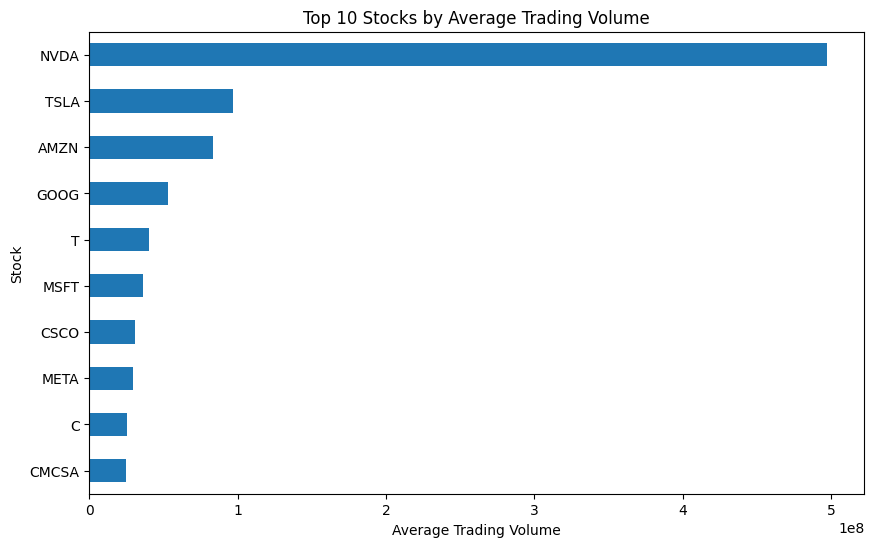

In [ ]:
plt.figure(figsize=(10, 6))

avg_volume.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Stocks by Average Trading Volume')
plt.xlabel('Average Trading Volume')
plt.ylabel('Stock')

plt.show()

# **EDA — Volume vs Volatility**

In [ ]:
stock_stats = df.groupby('Symbol').agg(
    Average_Volume=('Volume', 'mean'),
    Volatility=('Daily Return', 'std')
)

stock_stats.head()

,Average_Volume,Volatility
Symbol,,
ABBV,7.394091e+06,0.016683
ABT,8.270280e+06,0.013527
ADM,3.870529e+06,0.016347
AES,6.063514e+06,0.020075
AJG,8.711476e+05,0.012849


In [ ]:
correlation = stock_stats[
    ['Average_Volume', 'Volatility']
].corr()

correlation

,Average_Volume,Volatility
Average_Volume,1.000000,0.183461
Volatility,0.183461,1.000000


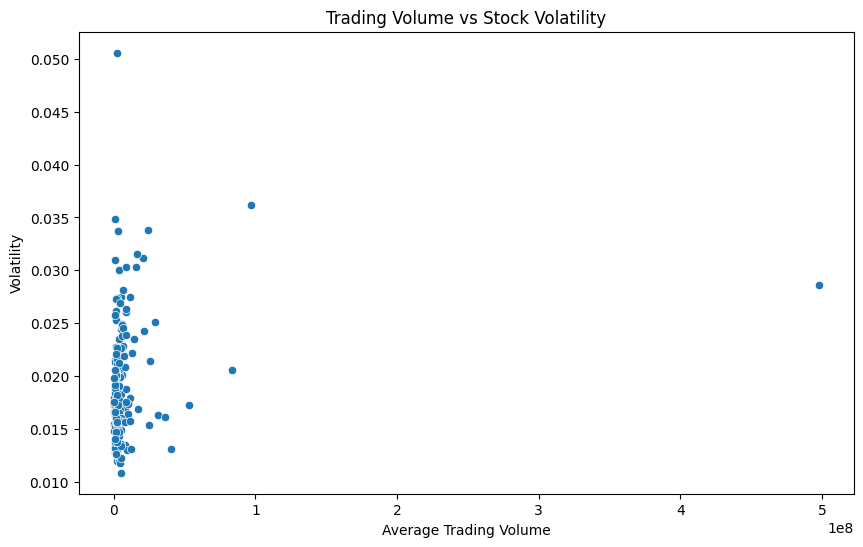

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=stock_stats,
    x='Average_Volume',
    y='Volatility'
)

plt.title('Trading Volume vs Stock Volatility')
plt.xlabel('Average Trading Volume')
plt.ylabel('Volatility')

plt.show()

# **Business Questions**

# **Step 10: Q1 — Which companies have the highest stock returns?**



In [ ]:
ret = sp500_stock_clean.groupby('Symbol').agg(first=('Close','first'), last=('Close','last'))
ret['Total Return %'] = (ret['last'] - ret['first']) / ret['first'] * 100
q1 = ret.sort_values('Total Return %', ascending=False).head(10)
q1

,first,last,Total Return %
Symbol,,,
NVDA,0.462250,134.699997,29040.075417
TSLA,1.592667,421.059998,26337.416101
AXON,4.650000,631.690002,13484.730957
NFLX,7.640000,909.049988,11798.560258
FTNT,1.800000,97.190002,5299.444723
DPZ,8.680000,426.179993,4809.907577
BLDR,3.770000,150.500000,3892.042461
DXCM,2.140000,80.040001,3640.186775
AMZN,6.695000,224.919998,3259.521918


# **Q2: Which companies have the lowest stock returns?**

In [ ]:
q2 = ret.sort_values('Total Return %').head(10)
q2

,first,last,Total Return %
Symbol,,,
BEN,36.000000,20.490000,-43.083334
VTRS,18.719999,12.520000,-33.119653
PARA,14.250000,10.660000,-25.192984
CCL,32.060001,26.799999,-16.406743
FCX,41.730000,38.860001,-6.877544
BAX,31.662140,29.500000,-6.828786
AES,13.670000,13.000000,-4.901244
SOLV,69.099998,66.830002,-3.285089
BKR,41.240002,40.320000,-2.230849


# **Q3: Which sectors perform the best based on stock returns?**

In [ ]:
sector_ret = sp500_stock_clean.groupby('Sector')['Daily Return'].mean().sort_values(ascending=False) * 100
sector_ret

,Daily Return
Sector,
Technology,0.090593
Consumer Cyclical,0.080005
Industrials,0.074457
Communication Services,0.068837
Healthcare,0.067522
Financial Services,0.061780
Basic Materials,0.051505
Energy,0.050712
Real Estate,0.046309


# **Q4: Which stocks are the most volatile?**

In [ ]:
vol = sp500_stock_clean.groupby('Symbol')['Daily Return'].std().sort_values(ascending=False)
q4 = vol.head(10)
q4

,Daily Return
Symbol,
ENPH,0.050573
TSLA,0.036132
BLDR,0.034879
UBER,0.033814
FSLR,0.033682
NFLX,0.031507
FCX,0.031184
AXON,0.030951
UAL,0.030359


# **Q5: Which companies have the highest trading volume?**

In [ ]:
avg_vol = sp500_stock_clean.groupby('Symbol')['Volume'].mean().sort_values(ascending=False)
q5 = avg_vol.head(10)
q5

,Volume
Symbol,
NVDA,4.975500e+08
TSLA,9.671530e+07
AMZN,8.331161e+07
GOOG,5.320426e+07
T,4.010495e+07
MSFT,3.620004e+07
CSCO,3.088401e+07
META,2.938322e+07
C,2.559602e+07


# **Q6: How does the S&P 500 index change over time?**

In [ ]:
print("Start:", sp500_ind.iloc[0]['S&P500'], "| End:", sp500_ind.iloc[-1]['S&P500'])
idx_change = (sp500_ind['S&P500'].iloc[-1] - sp500_ind['S&P500'].iloc[0]) / sp500_ind['S&P500'].iloc[0] * 100
print(f"Overall index change: {idx_change:.2f}%")

Start: 2078.54 | End: 5930.85
Overall index change: 185.34%


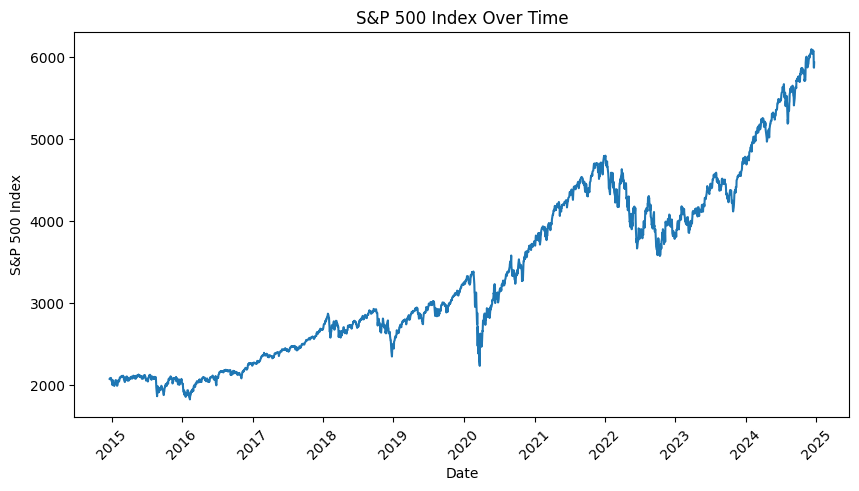

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    sp500_ind['Date'],
    sp500_ind['S&P500']
)

plt.title('S&P 500 Index Over Time')
plt.xlabel('Date')
plt.ylabel('S&P 500 Index')
plt.xticks(rotation=45)
plt.show()

# **Q7: Which month has the highest average market performance?**

In [ ]:
month_perf = sp500_stock_clean.groupby('Month')['Daily Return'].mean().sort_values(ascending=False) * 100
month_perf

,Daily Return
Month,
11,0.192546
7,0.134151
10,0.103365
2,0.090615
4,0.085465
3,0.076294
1,0.070833
12,0.036239
6,0.023769


# **Q8: Which sectors have the highest trading volume?**

In [ ]:
sector_vol = sp500_stock_clean.groupby('Sector')['Volume'].sum().sort_values(ascending=False)
sector_vol

,Volume
Sector,
Technology,2.592246e+12
Consumer Cyclical,9.466696e+11
Communication Services,7.093310e+11
Financial Services,4.337716e+11
Healthcare,2.586876e+11
Industrials,2.208075e+11
Consumer Defensive,1.635563e+11
Energy,1.259438e+11
Real Estate,1.121855e+11


# **Q9: Which companies outperform the S&P 500 index?**

In [ ]:
idx_ret = idx_change
outperform = ret[ret['Total Return %'] > idx_ret].sort_values('Total Return %', ascending=False)
print(f"Index return: {idx_ret:.2f}% | Companies beating it: {len(outperform)}")
outperform.head(10)

Index return: 185.34% | Companies beating it: 114


,first,last,Total Return %
Symbol,,,
NVDA,0.462250,134.699997,29040.075417
TSLA,1.592667,421.059998,26337.416101
AXON,4.650000,631.690002,13484.730957
NFLX,7.640000,909.049988,11798.560258
FTNT,1.800000,97.190002,5299.444723
DPZ,8.680000,426.179993,4809.907577
BLDR,3.770000,150.500000,3892.042461
DXCM,2.140000,80.040001,3640.186775
AMZN,6.695000,224.919998,3259.521918


# **Q10: Is there a relationship between trading volume and stock volatility?**

In [ ]:
vol_std = sp500_stock_clean.groupby('Symbol')['Daily Return'].std()
avg_volu = sp500_stock_clean.groupby('Symbol')['Volume'].mean()
corr = vol_std.corr(avg_volu)
print(f"Correlation between volatility and volume: {corr:.3f}")

Correlation between volatility and volume: 0.183


                Average_Volume  Volatility
Average_Volume        1.000000    0.183461
Volatility            0.183461    1.000000


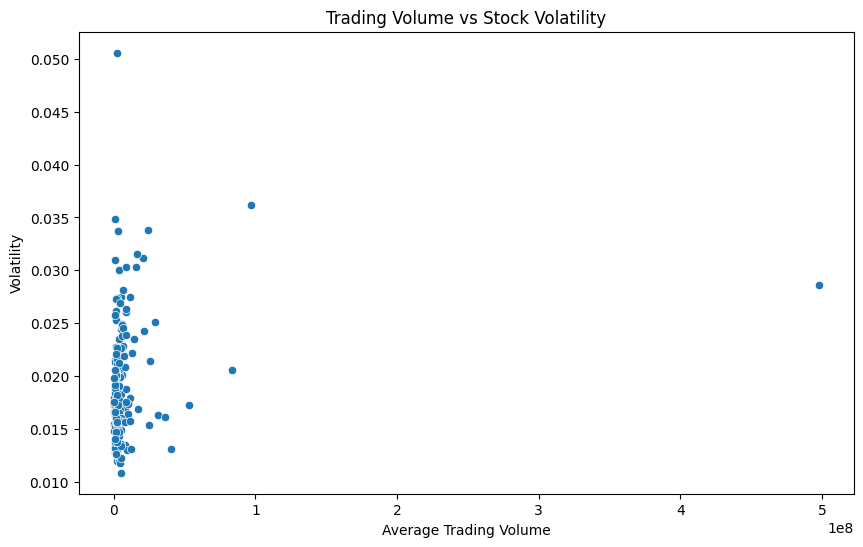

In [ ]:
stock_stats = df.groupby('Symbol').agg(
    Average_Volume=('Volume', 'mean'),
    Volatility=('Daily Return', 'std')
)

print(stock_stats.corr())

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=stock_stats,
    x='Average_Volume',
    y='Volatility'
)

plt.title('Trading Volume vs Stock Volatility')
plt.xlabel('Average Trading Volume')
plt.ylabel('Volatility')

plt.show()

# **Q11: Which companies have the highest price growth over the period?**

In [ ]:
q11 = ret.sort_values('Total Return %', ascending=False).head(10)
q11

,first,last,Total Return %
Symbol,,,
NVDA,0.462250,134.699997,29040.075417
TSLA,1.592667,421.059998,26337.416101
AXON,4.650000,631.690002,13484.730957
NFLX,7.640000,909.049988,11798.560258
FTNT,1.800000,97.190002,5299.444723
DPZ,8.680000,426.179993,4809.907577
BLDR,3.770000,150.500000,3892.042461
DXCM,2.140000,80.040001,3640.186775
AMZN,6.695000,224.919998,3259.521918


# **Q12: Which sectors are the most stable based on volatility?**

In [ ]:
sector_volatility = (
    df.groupby('Sector')['Daily Return']
      .std()
      .mul(100)
      .sort_values()
)

print("Q12 - Most stable sectors:")
print(sector_volatility)

Q12 - Most stable sectors:
Sector
Utilities                 1.403244
Consumer Defensive        1.504341
Real Estate               1.756647
Financial Services        1.795511
Healthcare                1.977008
Industrials               1.980030
Communication Services    2.093206
Basic Materials           2.143871
Consumer Cyclical         2.246902
Energy                    2.375221
Technology                2.450682
Name: Daily Return, dtype: float64


# **Q13: How does the performance of different sectors change over time?**

In [ ]:
sector_year = sp500_stock_clean.groupby(['Year','Sector'])['Daily Return'].mean().unstack() * 100
sector_year.tail()

Sector,Basic Materials,Communication Services,Consumer Cyclical,Consumer Defensive,Energy,Financial Services,Healthcare,Industrials,Real Estate,Technology,Utilities
Year,,,,,,,,,,,
2020,0.158750,0.079575,0.160154,0.047243,0.019320,0.070795,0.100842,0.129214,0.020512,0.191014,0.010930
2021,0.149253,0.039280,0.108851,0.064286,0.151022,0.117942,0.082952,0.103830,0.137905,0.149675,0.037413
2022,-0.086275,-0.115879,-0.103485,0.003555,0.182663,-0.017380,-0.015170,-0.036795,-0.090349,-0.062806,0.019630
2023,0.046522,0.108486,0.147126,-0.071225,0.030486,0.058183,0.020187,0.107620,0.065582,0.160116,-0.019645
2024,-0.059917,0.109456,0.076801,-0.006641,0.059689,0.111235,0.028862,0.075272,0.051639,0.128872,0.042667


# **Q14: Which stocks have the highest average closing price?**

In [ ]:
avg_close = sp500_stock_clean.groupby('Symbol')['Close'].mean().sort_values(ascending=False)
q14 = avg_close.head(10)
q14

,Close
Symbol,
MTD,645.048911
EQIX,426.076441
TDG,394.298474
NFLX,232.850524
FDS,227.038344
ESS,218.123944
DPZ,211.272131
PH,193.873360
META,184.816289


# **Q15: Which companies have the best risk-to-return performance?**

In [ ]:
risk_return = (ret['Total Return %'] / (vol_std * 100)).sort_values(ascending=False)
q15 = risk_return.head(10)
q15

,0
Symbol,
NVDA,10140.789603
TSLA,7289.164317
AXON,4356.825106
NFLX,3744.729025
DPZ,2540.993441
FTNT,2035.357402
AMZN,1580.422281
TDG,1253.839557
DXCM,1211.314005


# **Data Visualization**

# **Chart 1: Top 10 companies by return**

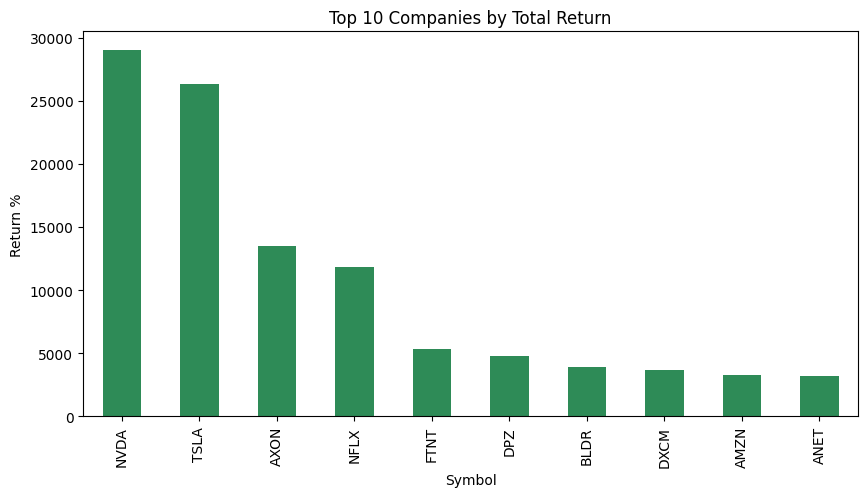

In [ ]:
plt.figure(figsize=(10,5))
q1['Total Return %'].plot(kind='bar', color='seagreen')
plt.title('Top 10 Companies by Total Return')
plt.ylabel('Return %')
plt.show()

# **Chart 2: Average return by sector**

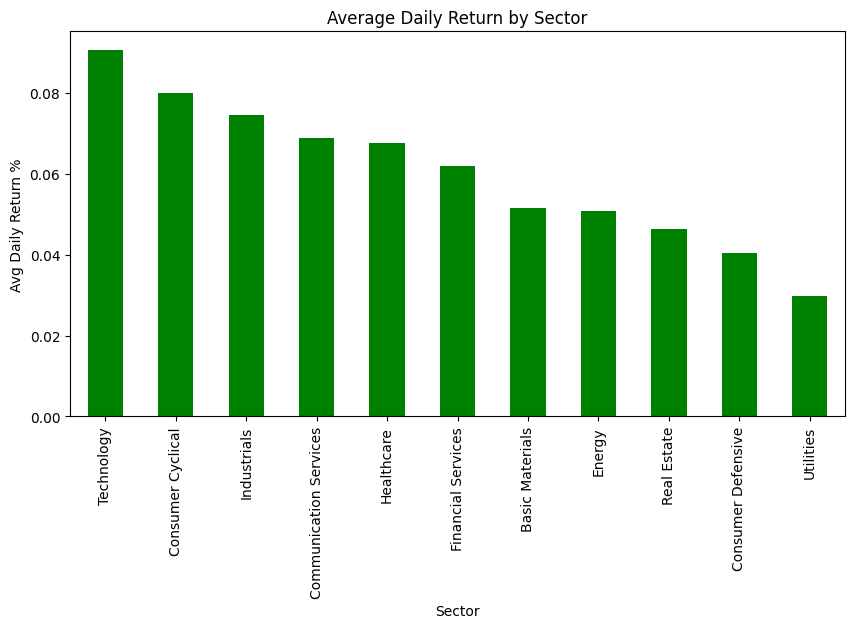

In [ ]:
plt.figure(figsize=(10,5))
sector_ret.plot(kind='bar', color='green')
plt.title('Average Daily Return by Sector')
plt.ylabel('Avg Daily Return %')
plt.show()

# **Chart 3: Trading volume by sector**

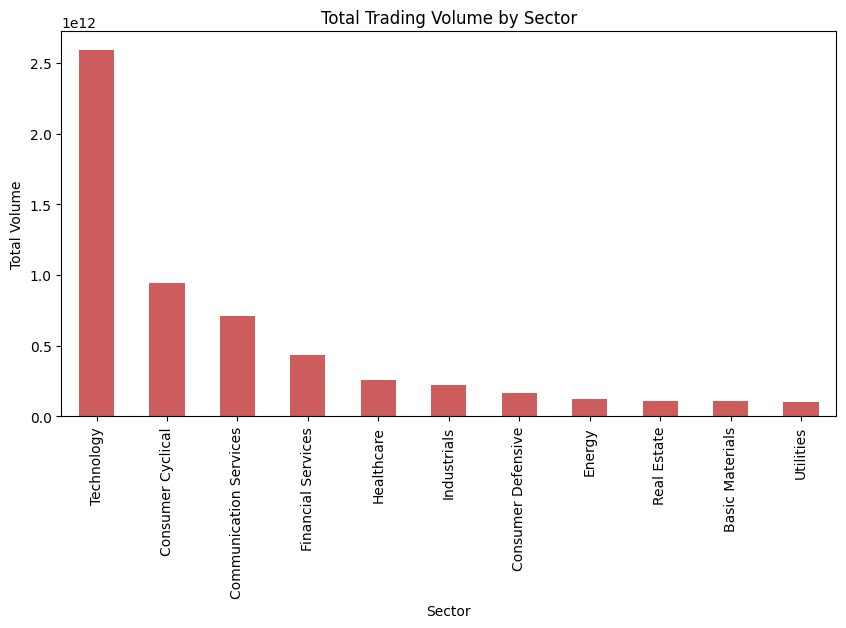

In [ ]:
plt.figure(figsize=(10,5))
sector_vol.plot(kind='bar', color='indianred')
plt.title('Total Trading Volume by Sector')
plt.ylabel('Total Volume')
plt.show()

# **Chart 4: Volatility vs Volume scatter**

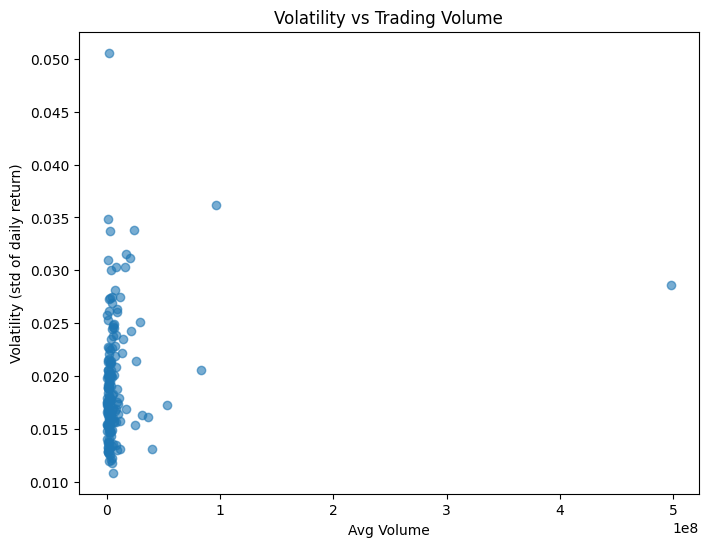

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(avg_volu, vol_std, alpha=0.6)
plt.xlabel('Avg Volume'); plt.ylabel('Volatility (std of daily return)')
plt.title('Volatility vs Trading Volume')
plt.show()

# **Insights & Conclusions**

## Insights

* Some stocks had higher returns than others.
* Some stocks were more volatile.
* Trading volume was different between companies and sectors.
* The S&P 500 changed over time.
* Some sectors performed better than others.
* Some companies performed better than the S&P 500.
* Stock performance changed across different months and years.

## Conclusion

The data shows that stock performance, volatility, and trading volume are different across companies and sectors.
